In [1]:
from sklearn.gaussian_process import GaussianProcessRegressor
from sklearn.gaussian_process.kernels import RBF
from scipy.stats import norm
import numpy as np
import matplotlib.pyplot as plt
from scipy.spatial.distance import pdist

In [2]:
#load
X1 =np.load('data/f2/updated_inputs.npy')
y1 = np.load('data/f2/updated_outputs.npy')# log-likelihood

In [3]:
# The best
best_f = np.max(y1)
best_idx = np.argmax(y1)
print(f"the best data is: X = {X1[best_idx]}, y_norm = {best_f:.4f}")
print('best f(x)=', best_f)

the best data is: X = [0.70263656 0.9265642 ], y_norm = 0.6112
best f(x)= 0.6112052157614438


In [4]:
# Compute distance for RBF lengthscale
distances = pdist(X1, metric='euclidean') # compute mean distance between data

In [5]:
#GP model
noise_assumption = 1e-2 # moderate noise
rbf_lengthscale  = .25*distances.mean()#first attempt with 50% of mean distance

kernel = RBF(length_scale=rbf_lengthscale, length_scale_bounds='fixed')
model  = GaussianProcessRegressor(kernel=kernel, alpha=noise_assumption)
model.fit(X1, y1)

,kernel,RBF(length_scale=0.121)
,alpha,0.01
,optimizer,'fmin_l_bfgs_b'
,n_restarts_optimizer,0
,normalize_y,False
,copy_X_train,True
,n_targets,None
,random_state,None
,kernel__length_scale,np.float64(0....0832817771651)
,kernel__length_scale_bounds,'fixed'


In [6]:
# Grid 2D for prediction
n_grid   = 30
x1_range = np.linspace(X1[:,0].min(), X1[:,0].max(), n_grid)
x2_range = np.linspace(X1[:,1].min(), X1[:,1].max(), n_grid)
#x1_range = np.linspace(0, 1, n_grid)
#x2_range = np.linspace(0, 1, n_grid)
xx1, xx2 = np.meshgrid(x1_range, x2_range)
x_grid_2d = np.column_stack([xx1.ravel(), xx2.ravel()])

In [7]:
#GP Prediction
post_mean, post_std = model.predict(x_grid_2d, return_std=True)

In [8]:
###  New adquisition Function EI (same GP)

In [9]:
def expected_improvement(mean, std, best_f, xi=0.01):
    Z  = (mean - best_f - xi) / (std + 1e-9)
    ei = (mean - best_f - xi) * norm.cdf(Z) + std * norm.pdf(Z)
    ei[std <= 0.0] = 0.0
    return ei

ei_values = expected_improvement(post_mean, post_std, best_f, xi=0.01)

In [10]:
# Calculate the maximum value
idx_next = np.argmax(ei_values)
x_next   = x_grid_2d[idx_next]
std_next = post_std[idx_next]
y_next = post_mean[idx_next]
print(f"proposed query(EI): x1={x_next[0]:.8f}, x2={x_next[1]:.8f}")
print('expected Y=', y_next)
print('with Std=', std_next)

#best from EI
x_next_ei = x_next
y_next_ei = y_next

proposed query(EI): x1=0.82709499, x2=0.92656420
expected Y= 0.5019686186667818
with Std= 0.6905550349934858


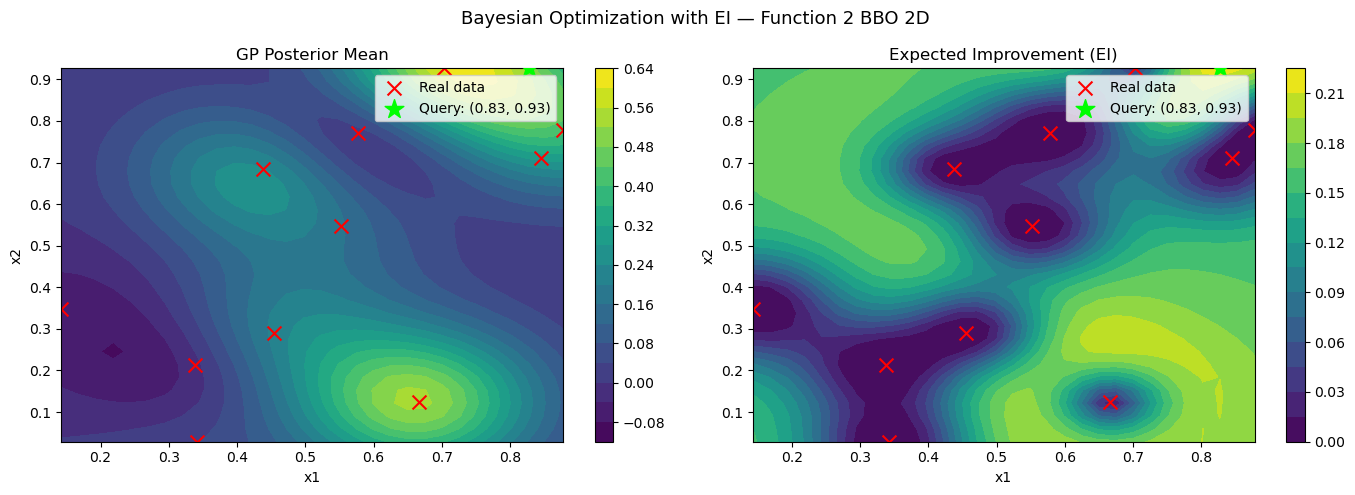

In [11]:
#graph
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for ax, values, title in zip(axes,
    [post_mean, ei_values],
    ['GP Posterior Mean', 'Expected Improvement (EI)']):

    Z_plot = values.reshape(n_grid, n_grid)
    cp = ax.contourf(xx1, xx2, Z_plot, levels=20, cmap='viridis')
    fig.colorbar(cp, ax=ax)
    ax.scatter(X1[:,0], X1[:,1], c='red', marker='x', s=100, label='Real data')
    ax.scatter(x_next[0], x_next[1], c='lime', marker='*', s=200, zorder=5, label=f'Query: ({x_next[0]:.2f}, {x_next[1]:.2f})')
    ax.set_xlabel('x1')
    ax.set_ylabel('x2')
    ax.set_title(title)
    ax.legend()

plt.suptitle('Bayesian Optimization with EI — Function 2 BBO 2D', fontsize=13)
plt.tight_layout()
plt.show()

In [12]:
    ## New adquisition Function UCB (same GP)

In [13]:
#UCB (maximize)
k = 0.1 #move to exploitation
#UCB
acquisition = post_mean + k * post_std
idx_next = np.argmax(acquisition)
x_next = x_grid_2d[idx_next]
std_next = post_std[idx_next]
y_next = post_mean[idx_next]
print(f"Proposed query (UCB): x1={x_next[0]:.8f}, x2={x_next[1]:.8f}")
print('expected Y=', y_next)
print('with Std=', std_next)

#best from UCB
x_next_ucb = x_next
y_next_ucb = y_next

Proposed query (UCB): x1=0.75105100, x2=0.92656420
expected Y= 0.6218543199440218
with Std= 0.3589377357666602


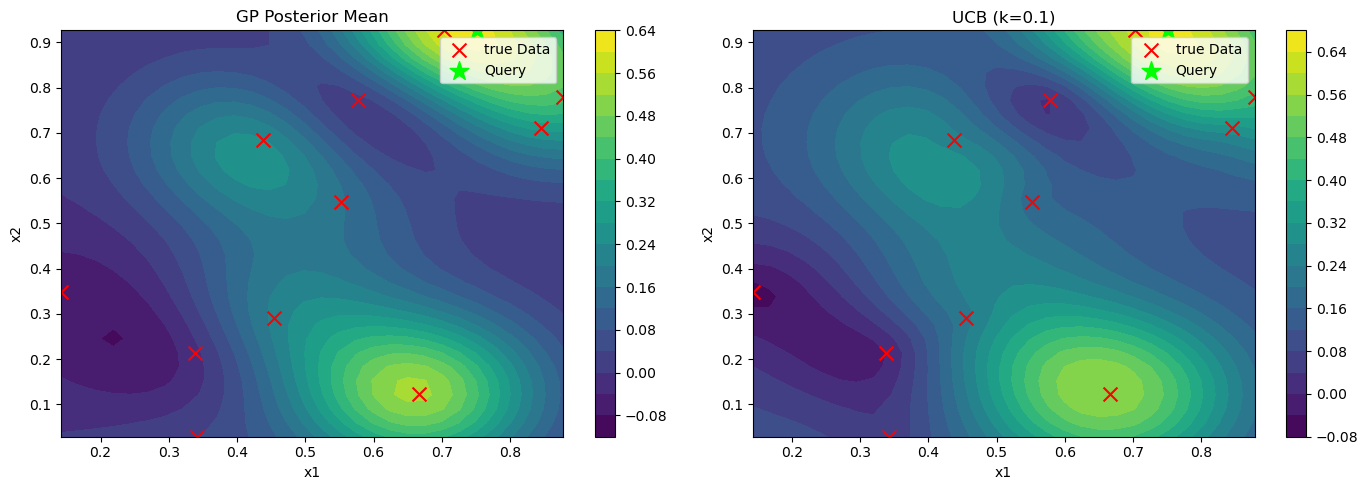

In [14]:
# Graph
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for ax, values, title in zip(axes,
    [post_mean, acquisition],
    ['GP Posterior Mean', f'UCB (k={k})']):
    
    Z = values.reshape(n_grid, n_grid)
    cp = ax.contourf(xx1, xx2, Z, levels=20, cmap='viridis')
    fig.colorbar(cp, ax=ax)
    ax.scatter(X1[:,0], X1[:,1], c='red', marker='x', s=100, label='true Data')
    ax.scatter(x_next[0], x_next[1], c='lime', marker='*', s=200, label='Query')
    ax.set_xlabel('x1')
    ax.set_ylabel('x2')
    ax.set_title(title)
    ax.legend()

plt.tight_layout()
plt.show()

In [15]:
# Choose the best option between EI and UCB
if y_next_ei > y_next_ucb:
    x_next_out = x_next_ei
else:
    x_next_out = x_next_ucb

# Write output file
import os
folder = 'results'
filename = 'output_F2.txt'
file_path = os.path.join(folder, filename)
with open(file_path, 'w', encoding='utf-8') as f:
    f.write(f"{x_next_out[0]:.6f} {x_next_out[1]:.6f}\n")